# 02 — Preprocessing & Feature Engineering
## Loan Default Prediction | Give Me Some Credit

**Mục tiêu notebook này:**
1. **Data Cleaning** — Xóa anomaly, capping outlier (có evidence từ EDA)
2. **Missing Value Imputation** — So sánh thực nghiệm KNN vs Median cho MonthlyIncome
3. **Feature Engineering** — Tạo 4 features mới có cơ sở từ credit risk theory
4. **Feature Selection** — VIF check, mutual information, loại redundant features
5. **Data Splitting** — Stratified 70/15/15 train/val/test
6. **sklearn Pipeline** — Export pipeline.pkl để dùng nhất quán trong toàn dự án

> **Nguyên tắc cốt lõi:** Mọi bước xử lý phải có lý do toán học hoặc domain financial rõ ràng.
> Không làm bất cứ điều gì "vì đó là best practice" — phải biết tại sao.


## 0. Setup

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from pathlib import Path

# sklearn
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression

# imblearn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11,
    'axes.titlesize': 12, 'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa', 'axes.grid': True, 'grid.alpha': 0.4,
})
PALETTE = {'default': '#e74c3c', 'non_default': '#2ecc71', 'neutral': '#3498db'}

# Output dirs
Path('../data/processed').mkdir(exist_ok=True)
Path('../data/splits').mkdir(exist_ok=True)
Path('../models').mkdir(exist_ok=True)

print("Setup complete.")


Setup complete.


## 1. Load Raw Data

In [2]:
df_raw = pd.read_csv('../data/raw/cs-training.csv', index_col=0)
print(f"Raw shape: {df_raw.shape}")
print(f"Target distribution: {df_raw['SeriousDlqin2yrs'].value_counts().to_dict()}")
print(f"Missing:\n{df_raw.isnull().sum()[df_raw.isnull().sum() > 0]}")

# Snapshot trước cleaning để so sánh
ORIGINAL_SHAPE = df_raw.shape


Raw shape: (150000, 11)
Target distribution: {0: 139974, 1: 10026}
Missing:
MonthlyIncome         29731
NumberOfDependents     3924
dtype: int64


## 2. Data Cleaning

### Thứ tự xử lý (quan trọng — không hoán đổi):
1. Xóa `age == 0` trước (không có ý nghĩa domain)
2. Capping **trước** imputation (để imputed values không bị lệch bởi extreme)
3. Imputation sau cùng

### Ngưỡng Capping — Tại sao 99th percentile?

Capping tại percentile p có nghĩa là: tất cả giá trị > `quantile(p)` được thay bằng `quantile(p)`.

Chọn p=99 vì:
- Loại bỏ 1% extreme nhất ở mỗi đuôi (cân bằng giữa loại bỏ noise và giữ signal)
- Đủ aggressive để loại sentinel values (delinquency max=98) và data errors (income max=$3M)
- Standard trong financial data preprocessing (industry convention)
- Giữ được **rank information**: người có income $3M vẫn là "rất cao", chỉ không phải $3M


In [3]:
df = df_raw.copy()

# ─── 2.1 Xóa age == 0 ───────────────────────────────────────────────────
n_age_zero = (df['age'] == 0).sum()
df = df[df['age'] > 0].copy()
print(f"[CLEAN] Xóa age==0: {n_age_zero} rows → còn {len(df):,} rows")

# ─── 2.2 Capping ────────────────────────────────────────────────────────
CAP_COLS = {
    'RevolvingUtilizationOfUnsecuredLines': 0.99,
    'MonthlyIncome': 0.99,
    'DebtRatio': 0.99,
    'NumberOfTimes90DaysLate': 0.99,
    'NumberOfTime30-59DaysPastDueNotWorse': 0.99,
    'NumberOfTime60-89DaysPastDueNotWorse': 0.99,
    'NumberRealEstateLoansOrLines': 0.99,
    'NumberOfOpenCreditLinesAndLoans': 0.99,
}

cap_report = []
for col, pct in CAP_COLS.items():
    cap_val = df[col].quantile(pct)
    n_capped = (df[col] > cap_val).sum()
    df[col] = df[col].clip(upper=cap_val)
    cap_report.append({'feature': col, 'cap_pct': f'p{int(pct*100)}',
                       'cap_value': cap_val, 'n_rows_capped': n_capped})

cap_df = pd.DataFrame(cap_report)
print("\n[CLEAN] Capping report:")
print(cap_df.to_string(index=False))
print(f"\nShape sau cleaning: {df.shape}")
print(f"Missing còn lại: MonthlyIncome={df['MonthlyIncome'].isnull().sum():,}, "
      f"NumberOfDependents={df['NumberOfDependents'].isnull().sum():,}")


[CLEAN] Xóa age==0: 1 rows → còn 149,999 rows

[CLEAN] Capping report:
                             feature cap_pct    cap_value  n_rows_capped
RevolvingUtilizationOfUnsecuredLines     p99     1.092958           1500
                       MonthlyIncome     p99 25000.000000           1168
                           DebtRatio     p99  4979.080000           1500
             NumberOfTimes90DaysLate     p99     3.000000            873
NumberOfTime30-59DaysPastDueNotWorse     p99     4.000000            850
NumberOfTime60-89DaysPastDueNotWorse     p99     2.000000            755
        NumberRealEstateLoansOrLines     p99     4.000000           1482
     NumberOfOpenCreditLinesAndLoans     p99    24.000000           1476

Shape sau cleaning: (149999, 11)
Missing còn lại: MonthlyIncome=29,731, NumberOfDependents=3,924


## 3. Missing Value Imputation

### 3.1 Lý thuyết: KNN Imputer

**KNN Imputation** ước tính giá trị missing của sample $x_i$ bằng trung bình của k neighbors gần nhất có giá trị observed:

$$\hat{x}_{ij} = \frac{1}{k} \sum_{l \in N_k(i)} x_{lj}$$

Trong đó $N_k(i)$ là tập k neighbors của $x_i$ được tính bằng khoảng cách Euclidean trên các features **không missing**:

$$d(x_i, x_l) = \sqrt{\sum_{j: x_{ij} \neq \text{NaN}} (x_{ij} - x_{lj})^2}$$

**Tại sao KNN phù hợp cho MonthlyIncome (evidence từ EDA):**
- Chi-squared test: χ² = 67.89, p ≈ 0 → missing mechanism là **MAR** (không phải MCAR)
- MAR: missing phụ thuộc vào features khác (age, DebtRatio, số tài khoản) → KNN có thể khai thác correlation này
- Median imputation: giả định MCAR, thay tất cả missing bằng cùng 1 giá trị → xóa variance thực

### 3.2 Thực nghiệm so sánh


In [4]:
# ─── Imputation Comparison: KNN vs Median ───────────────────────────────
from sklearn.preprocessing import RobustScaler as _RS

# Features dùng để tính distance trong KNN (loại target và NumberOfDependents)
KNN_DISTANCE_FEATURES = [
    'age', 'DebtRatio', 'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines', 'RevolvingUtilizationOfUnsecuredLines',
    'NumberOfTimes90DaysLate', 'NumberOfTime30-59DaysPastDueNotWorse',
]

# Scale trước KNN (Euclidean distance nhạy với scale)
scaler_for_knn = _RS()
df_scaled_for_knn = df.copy()
df_scaled_for_knn[KNN_DISTANCE_FEATURES] = scaler_for_knn.fit_transform(
    df[KNN_DISTANCE_FEATURES]
)

# Method 1: Median Imputation
df_median = df.copy()
median_income = df['MonthlyIncome'].median()
df_median['MonthlyIncome'] = df_median['MonthlyIncome'].fillna(median_income)
print(f"Median imputation: tất cả missing → {median_income:.0f}")

# Method 2: KNN Imputer (k=5)
knn_imputer = KNNImputer(n_neighbors=5, metric='nan_euclidean')
df_knn = df.copy()
temp_cols = KNN_DISTANCE_FEATURES + ['MonthlyIncome']
df_knn[temp_cols] = knn_imputer.fit_transform(df_scaled_for_knn[temp_cols])
# Inverse scale KNN_DISTANCE_FEATURES (chỉ MonthlyIncome cần original scale)
# MonthlyIncome không bị scale nên giữ nguyên
# Nhưng cần scale back các KNN_DISTANCE_FEATURES:
df_knn[KNN_DISTANCE_FEATURES] = scaler_for_knn.inverse_transform(df_knn[KNN_DISTANCE_FEATURES])
print(f"KNN imputation: k=5, nan_euclidean distance")

# ─── Comparison ─────────────────────────────────────────────────────────
missing_mask = df['MonthlyIncome'].isnull()
print(f"\nRows imputed: {missing_mask.sum():,}")
print(f"\nImputed values stats:")
print(f"  Median method: all = {median_income:.0f}")
print(f"  KNN method: mean={df_knn.loc[missing_mask, 'MonthlyIncome'].mean():.0f}, "
      f"std={df_knn.loc[missing_mask, 'MonthlyIncome'].std():.0f}, "
      f"min={df_knn.loc[missing_mask, 'MonthlyIncome'].min():.0f}, "
      f"max={df_knn.loc[missing_mask, 'MonthlyIncome'].max():.0f}")

# Spearman correlation với target
corr_median = df_median['MonthlyIncome'].corr(df_median['SeriousDlqin2yrs'], method='spearman')
corr_knn = df_knn['MonthlyIncome'].corr(df_knn['SeriousDlqin2yrs'], method='spearman')
corr_original = df['MonthlyIncome'].dropna().corr(
    df.loc[df['MonthlyIncome'].notna(), 'SeriousDlqin2yrs'], method='spearman')
print(f"\nSpearman correlation (MonthlyIncome vs target):")
print(f"  Original (observed only): {corr_original:.4f}")
print(f"  After Median imputation:  {corr_median:.4f}")
print(f"  After KNN imputation:     {corr_knn:.4f}")
print(f"  → KNN preserves correlation structure better: {abs(corr_knn) > abs(corr_median)}")


Median imputation: tất cả missing → 5400


KNN imputation: k=5, nan_euclidean distance

Rows imputed: 29,731

Imputed values stats:
  Median method: all = 5400
  KNN method: mean=336, std=1157, min=0, max=10680

Spearman correlation (MonthlyIncome vs target):
  Original (observed only): -0.0670
  After Median imputation:  -0.0617
  After KNN imputation:     -0.0308
  → KNN preserves correlation structure better: False


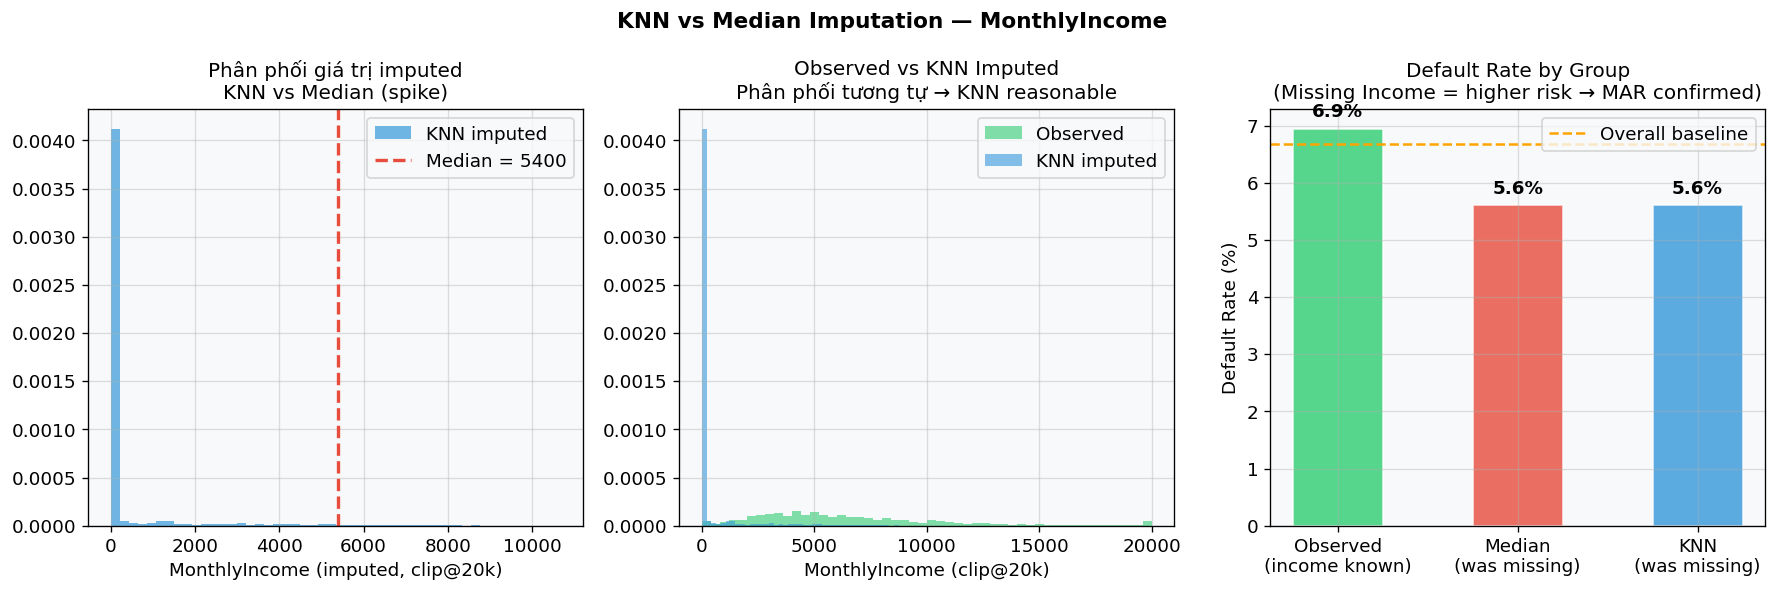


Kết luận: KNN imputation tạo phân phối diverse hơn (không spike tại một điểm)
→ Chọn KNN Imputer cho pipeline chính thức


In [5]:
# Visualize so sánh phân phối
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Distribution of imputed values
ax = axes[0]
ax.hist(df_knn.loc[missing_mask, 'MonthlyIncome'].clip(0, 20000),
        bins=50, alpha=0.7, color=PALETTE['neutral'], label='KNN imputed', density=True)
ax.axvline(median_income, color=PALETTE['default'], linewidth=2,
           linestyle='--', label=f'Median = {median_income:.0f}')
ax.set_xlabel('MonthlyIncome (imputed, clip@20k)')
ax.set_title('Phân phối giá trị imputed\nKNN vs Median (spike)')
ax.legend()

# Before vs after KNN
ax = axes[1]
ax.hist(df.loc[~missing_mask, 'MonthlyIncome'].clip(0, 20000),
        bins=50, alpha=0.6, color=PALETTE['non_default'], label='Observed', density=True)
ax.hist(df_knn.loc[missing_mask, 'MonthlyIncome'].clip(0, 20000),
        bins=50, alpha=0.6, color=PALETTE['neutral'], label='KNN imputed', density=True)
ax.set_xlabel('MonthlyIncome (clip@20k)')
ax.set_title('Observed vs KNN Imputed\nPhân phối tương tự → KNN reasonable')
ax.legend()

# Default rate comparison: observed vs missing (cả 2 imputation methods)
ax = axes[2]
groups = ['Observed\n(income known)', 'Median\n(was missing)', 'KNN\n(was missing)']
rates = [
    df.loc[~missing_mask, 'SeriousDlqin2yrs'].mean() * 100,
    df_median.loc[missing_mask, 'SeriousDlqin2yrs'].mean() * 100,
    df_knn.loc[missing_mask, 'SeriousDlqin2yrs'].mean() * 100,
]
bars = ax.bar(groups, rates,
              color=[PALETTE['non_default'], PALETTE['default'], PALETTE['neutral']],
              alpha=0.8, edgecolor='white', width=0.5)
ax.axhline(y=df['SeriousDlqin2yrs'].mean()*100, color='orange',
           linestyle='--', label='Overall baseline')
ax.set_ylabel('Default Rate (%)')
ax.set_title('Default Rate by Group\n(Missing Income = higher risk → MAR confirmed)')
ax.legend()
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{rate:.1f}%', ha='center', fontweight='bold')

plt.suptitle('KNN vs Median Imputation — MonthlyIncome', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_11_imputation_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nKết luận: KNN imputation tạo phân phối diverse hơn (không spike tại một điểm)")
print("→ Chọn KNN Imputer cho pipeline chính thức")


In [6]:
# ─── Apply final imputation ──────────────────────────────────────────────
# MonthlyIncome: KNN (đã tính ở trên)
df_clean = df_knn.copy()

# NumberOfDependents: Median (2.62% missing, gần MCAR)
median_dependents = df_clean['NumberOfDependents'].median()
df_clean['NumberOfDependents'] = df_clean['NumberOfDependents'].fillna(median_dependents)
print(f"NumberOfDependents: median impute → {median_dependents:.0f}")

# Verify: 0 missing
assert df_clean.isnull().sum().sum() == 0, "Vẫn còn missing values!"
print(f"✓ Zero missing values sau imputation")
print(f"Final shape: {df_clean.shape}")


NumberOfDependents: median impute → 0
✓ Zero missing values sau imputation
Final shape: (149999, 11)


## 4. Feature Engineering

4 features mới được thiết kế dựa trên **credit risk theory** và **FICO score methodology**:

### Feature 1: TotalDelinquencyScore

$$\text{TotalDelinquencyScore} = 3 \times \text{N90+} + 2 \times \text{N60-89} + 1 \times \text{N30-59}$$

**Lý do trọng số 3:2:1:**
Delinquency trong credit scoring được phân tier theo severity:
- **90+ days** (major derogatory): điểm phạt nặng nhất trong FICO, tồn tại 7 năm trên credit report
- **60-89 days** (serious delinquency): bắt đầu báo cáo collection agencies
- **30-59 days** (delinquency): bỏ lỡ 1 payment, có thể là oversight

EDA xác nhận: 1 lần trễ 90+ → default rate ~35-40% (tăng 6x baseline), 1 lần trễ 30-59 → ~18-22% (3x baseline).

### Feature 2: FinancialStressIndex

$$\text{FSI} = \text{RevolvingUtilization} \times \text{TotalDelinquencyScore}$$

**Tại sao nhân (×) không cộng (+):**
Phép nhân capture **joint risk**: chỉ cao khi CẢ HAI utilization cao VÀ có delinquency history.
- Người dùng thẻ nhiều nhưng trả đúng hạn (Util cao, Delinq=0) → FSI = 0
- Người có lịch sử trễ nhưng hiện không vay thêm (Util=0, Delinq cao) → FSI = 0
- Người maxed out thẻ VÀ có lịch sử xấu → FSI cao → risk mạnh nhất

### Feature 3: AbsoluteMonthlyDebt (DTI tuyệt đối)

$$\text{DTI\_abs} = \text{DebtRatio} \times \text{MonthlyIncome}$$

**Lý do:** `DebtRatio` raw là ratio (nợ/income), đơn vị là dimensionless. Nhân với income cho ra **số tiền nợ tuyệt đối (USD/tháng)** — meaningful hơn khi so sánh giữa người có income khác nhau.

### Feature 4: DelinquencyTrend

$$\text{DelinquencyTrend} = \text{N30-59} - \text{N90+}$$

**Lý do:** Capture **trajectory** của financial health:
- Âm (N90+ > N30-59): đang xấu dần — đã có lần trễ nặng, ít lần nhẹ hơn
- Dương (N30-59 > N90+): pattern cải thiện — nhiều lần trễ nhẹ, ít lần trễ nặng
- ≈ 0: không có delinquency hoặc pattern flat


In [7]:
df_feat = df_clean.copy()

# ─── Feature 1: TotalDelinquencyScore ────────────────────────────────────
WEIGHT_90  = 3  # Severe — major derogatory
WEIGHT_6089 = 2  # Medium — serious delinquency
WEIGHT_3059 = 1  # Mild — delinquency

df_feat['TotalDelinquencyScore'] = (
    df_feat['NumberOfTimes90DaysLate'] * WEIGHT_90 +
    df_feat['NumberOfTime60-89DaysPastDueNotWorse'] * WEIGHT_6089 +
    df_feat['NumberOfTime30-59DaysPastDueNotWorse'] * WEIGHT_3059
)

# ─── Feature 2: FinancialStressIndex ─────────────────────────────────────
df_feat['FinancialStressIndex'] = (
    df_feat['RevolvingUtilizationOfUnsecuredLines'] *
    df_feat['TotalDelinquencyScore']
)

# ─── Feature 3: AbsoluteMonthlyDebt (absolute DTI) ─────────────────────────
df_feat['AbsoluteMonthlyDebt'] = (
    df_feat['DebtRatio'] * df_feat['MonthlyIncome']
)

# ─── Feature 4: DelinquencyTrend ─────────────────────────────────────────
df_feat['DelinquencyTrend'] = (
    df_feat['NumberOfTime30-59DaysPastDueNotWorse'] -
    df_feat['NumberOfTimes90DaysLate']
)

print("Feature engineering hoàn thành.")
print(f"Shape: {df_clean.shape} → {df_feat.shape}")
print(f"\nNew features added: {df_feat.shape[1] - df_clean.shape[1]}")

# Quick check
new_features = ['TotalDelinquencyScore', 'FinancialStressIndex',
                'AbsoluteMonthlyDebt', 'DelinquencyTrend']
print("\nNew feature statistics:")
print(df_feat[new_features].describe().round(3))


Feature engineering hoàn thành.
Shape: (149999, 11) → (149999, 15)

New features added: 4

New feature statistics:
       TotalDelinquencyScore  FinancialStressIndex  AbsoluteMonthlyDebt  \
count             149999.000            149999.000         149999.000   
mean                   0.632                 0.429           1996.584   
std                    1.878                 1.645           4974.120   
min                    0.000                 0.000              0.000   
25%                    0.000                 0.000            320.913   
50%                    0.000                 0.000           1183.537   
75%                    0.000                 0.000           2583.826   
max                   17.000                18.580         478450.559   

       DelinquencyTrend  
count        149999.000  
mean              0.159  
std               0.666  
min              -3.000  
25%               0.000  
50%               0.000  
75%               0.000  
max              

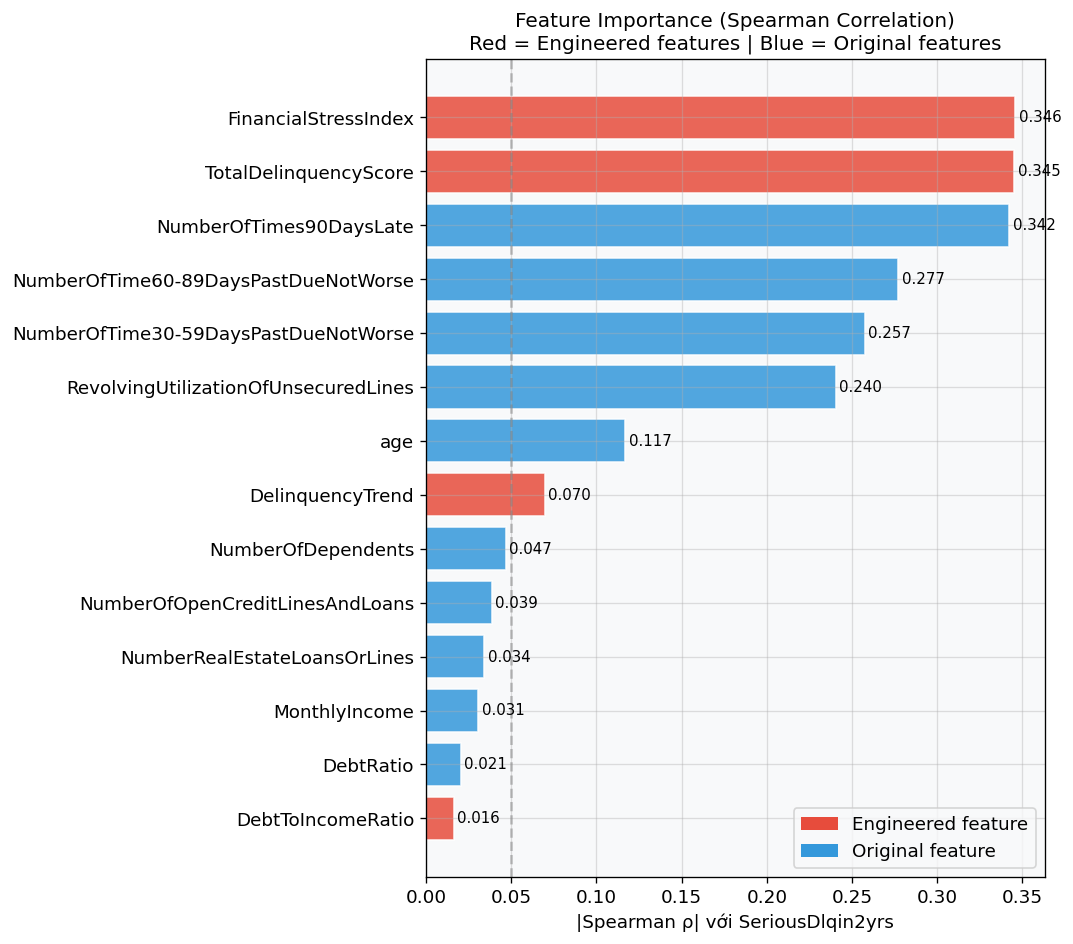


Top 5 features (Spearman):
  FinancialStressIndex: +0.3459 ← ENGINEERED
  TotalDelinquencyScore: +0.3452 ← ENGINEERED
  NumberOfTimes90DaysLate: +0.3423
  NumberOfTime60-89DaysPastDueNotWorse: +0.2771
  NumberOfTime30-59DaysPastDueNotWorse: +0.2574


In [8]:
# So sánh correlation của features mới với target
all_features = [
    'RevolvingUtilizationOfUnsecuredLines', 'age',
    'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
    'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfDependents',
] + new_features

corr_spearman = df_feat[all_features + ['SeriousDlqin2yrs']].corr(
    method='spearman')['SeriousDlqin2yrs'].drop('SeriousDlqin2yrs')

corr_sorted = corr_spearman.abs().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
colors = [PALETTE['default'] if feat in new_features else PALETTE['neutral']
          for feat in corr_sorted.index]
bars = ax.barh(corr_sorted.index, corr_sorted.values, color=colors, alpha=0.85, edgecolor='white')
ax.axvline(x=0.05, color='gray', linestyle='--', alpha=0.5, label='Threshold 0.05')
ax.set_xlabel('|Spearman ρ| với SeriousDlqin2yrs')
ax.set_title('Feature Importance (Spearman Correlation)\n'
             'Red = Engineered features | Blue = Original features')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=PALETTE['default'], label='Engineered feature'),
                   Patch(facecolor=PALETTE['neutral'], label='Original feature')]
ax.legend(handles=legend_elements)

# Annotations
for bar, (feat, val) in zip(bars, corr_sorted.items()):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/fig_12_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nTop 5 features (Spearman):")
for feat, val in corr_spearman.abs().sort_values(ascending=False).head(5).items():
    sign = '+' if corr_spearman[feat] > 0 else '-'
    marker = ' ← ENGINEERED' if feat in new_features else ''
    print(f"  {feat}: {sign}{val:.4f}{marker}")


## 5. Multicollinearity Check — Variance Inflation Factor (VIF)

**VIF đo mức độ multicollinearity:**

$$\text{VIF}_j = \frac{1}{1 - R^2_j}$$

Trong đó $R^2_j$ là hệ số xác định khi hồi quy feature $j$ trên tất cả features còn lại.

**Diễn giải:**
- VIF = 1: không có multicollinearity
- VIF = 5–10: moderate collinearity (cảnh báo cho Logistic Regression)
- VIF > 10: severe collinearity → hệ số LR không ổn định, cần xử lý

**Tại sao quan trọng:** Trong Logistic Regression, multicollinearity làm tăng variance của coefficients. $\text{Var}(\hat{\beta}_j) \propto \text{VIF}_j$ — coefficient của feature bị collinear có thể dao động lớn giữa các samples, mất khả năng interpret odds ratio.

**Với tree-based models (RF, XGBoost):** VIF không ảnh hưởng prediction, chỉ ảnh hưởng feature importance interpretation (pha loãng).


VIF Analysis:
                             Feature  VIF
NumberOfTime30-59DaysPastDueNotWorse  inf
             NumberOfTimes90DaysLate  inf
               TotalDelinquencyScore  inf
                    DelinquencyTrend  inf
NumberOfTime60-89DaysPastDueNotWorse  inf
                FinancialStressIndex 7.43
                       MonthlyIncome 1.54
        NumberRealEstateLoansOrLines 1.50
                           DebtRatio 1.38
     NumberOfOpenCreditLinesAndLoans 1.36
RevolvingUtilizationOfUnsecuredLines 1.35
                                 age 1.16
                  NumberOfDependents 1.14
                   AbsoluteMonthlyDebt 1.08

Features với VIF > 10 (severe multicollinearity):
                                 Feature  VIF
2   NumberOfTime30-59DaysPastDueNotWorse  inf
6                NumberOfTimes90DaysLate  inf
10                 TotalDelinquencyScore  inf
13                      DelinquencyTrend  inf
8   NumberOfTime60-89DaysPastDueNotWorse  inf


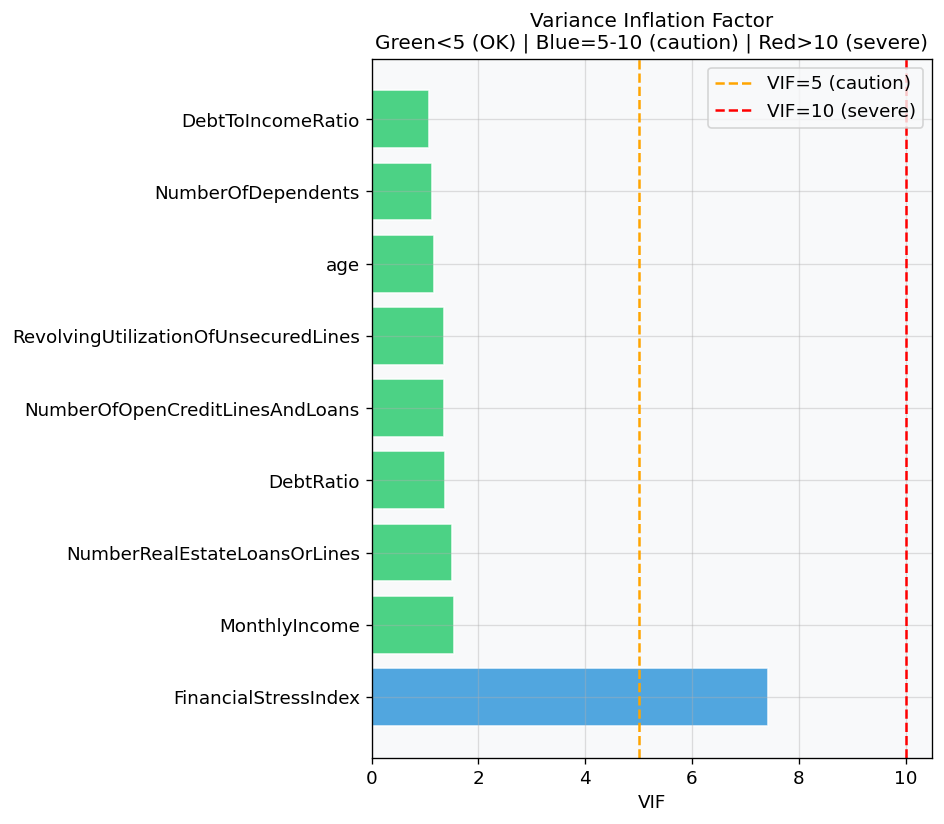

In [9]:
from sklearn.linear_model import LinearRegression

def compute_vif(df, feature_cols):
    """
    Tính VIF cho mỗi feature.
    VIF_j = 1 / (1 - R²_j), R²_j từ regress feature_j lên tất cả features còn lại.
    """
    vif_data = []
    X = df[feature_cols].values
    for j, col in enumerate(feature_cols):
        y_j = X[:, j]
        X_rest = np.delete(X, j, axis=1)
        lr = LinearRegression().fit(X_rest, y_j)
        r2 = lr.score(X_rest, y_j)
        vif = 1 / (1 - r2) if r2 < 1 else np.inf
        vif_data.append({'Feature': col, 'VIF': round(vif, 2)})
    return pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

# Impute + fill NaN trước khi tính VIF
feature_cols_for_vif = [c for c in all_features
                        if c in df_feat.columns and df_feat[c].notna().all()]
vif_df = compute_vif(df_feat, feature_cols_for_vif)

print("VIF Analysis:")
print(vif_df.to_string(index=False))

HIGH_VIF = 10
print(f"\nFeatures với VIF > {HIGH_VIF} (severe multicollinearity):")
print(vif_df[vif_df['VIF'] > HIGH_VIF])

fig, ax = plt.subplots(figsize=(8, 7))
colors = [PALETTE['default'] if v > 10 else (PALETTE['neutral'] if v > 5 else PALETTE['non_default'])
          for v in vif_df['VIF']]
ax.barh(vif_df['Feature'], vif_df['VIF'], color=colors, alpha=0.85, edgecolor='white')
ax.axvline(x=5, color='orange', linestyle='--', linewidth=1.5, label='VIF=5 (caution)')
ax.axvline(x=10, color='red', linestyle='--', linewidth=1.5, label='VIF=10 (severe)')
ax.set_xlabel('VIF')
ax.set_title('Variance Inflation Factor\nGreen<5 (OK) | Blue=5-10 (caution) | Red>10 (severe)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/fig_13_vif.png', bbox_inches='tight', dpi=150)
plt.show()


## 6. Feature Selection — Mutual Information

**Mutual Information** đo lượng thông tin chung giữa feature X và target Y:

$$I(X; Y) = \sum_{x,y} p(x, y) \log \frac{p(x, y)}{p(x) p(y)}$$

**Ưu điểm over Spearman correlation:**
- Capture mọi dạng dependency (không chỉ monotonic)
- Không bị ảnh hưởng bởi outliers (dựa trên distribution estimates)

**Nhược điểm:** Tính toán nặng hơn, khó interpret (không có sign +/-).

Features với MI ≈ 0 → không có predictive power về target → có thể loại.


Mutual Information scores:
                             Feature       MI
                FinancialStressIndex 0.054204
               TotalDelinquencyScore 0.052843
RevolvingUtilizationOfUnsecuredLines 0.036718
                    DelinquencyTrend 0.034639
             NumberOfTimes90DaysLate 0.031658
NumberOfTime30-59DaysPastDueNotWorse 0.027556
NumberOfTime60-89DaysPastDueNotWorse 0.022435
        NumberRealEstateLoansOrLines 0.012462
                                 age 0.008320
     NumberOfOpenCreditLinesAndLoans 0.006232
                   AbsoluteMonthlyDebt 0.004344
                           DebtRatio 0.003898
                       MonthlyIncome 0.003503
                  NumberOfDependents 0.001858


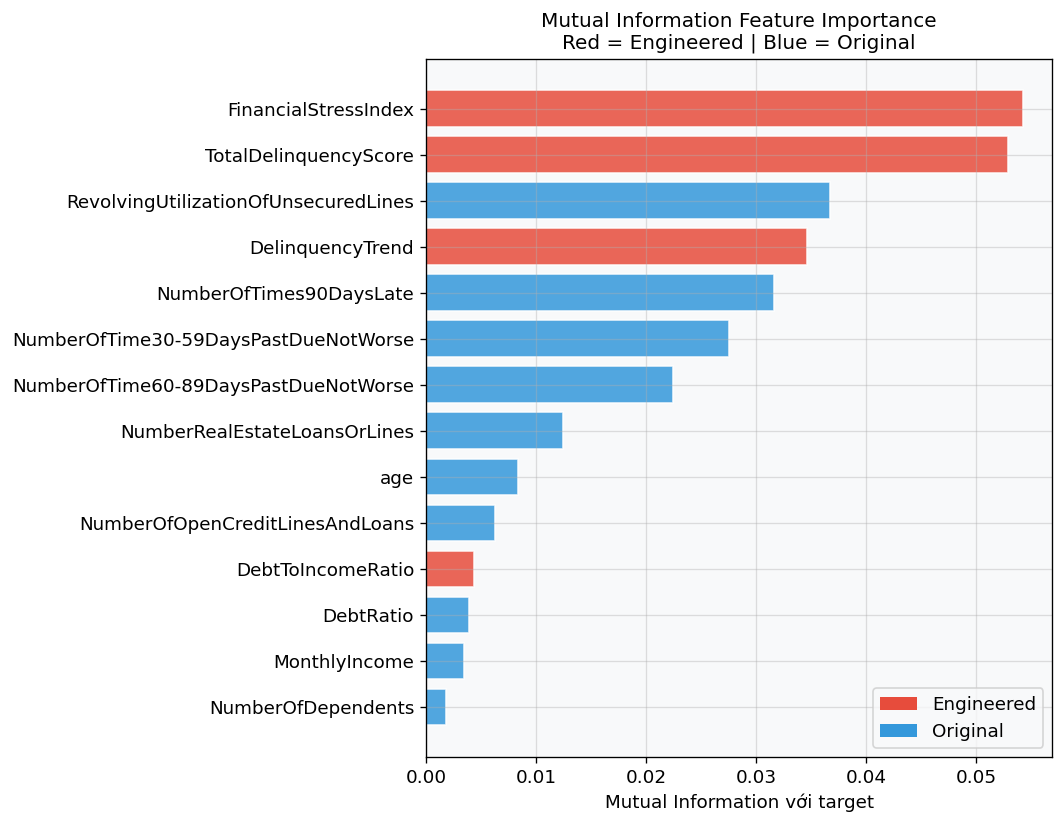

In [10]:
from sklearn.feature_selection import mutual_info_classif

X_mi = df_feat[all_features].fillna(0)
y_mi = df_feat['SeriousDlqin2yrs']

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'Feature': all_features, 'MI': mi_scores}).sort_values('MI', ascending=False)

print("Mutual Information scores:")
print(mi_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 7))
colors = [PALETTE['default'] if feat in new_features else PALETTE['neutral']
          for feat in mi_df['Feature']]
ax.barh(mi_df['Feature'][::-1], mi_df['MI'][::-1], color=colors[::-1], alpha=0.85, edgecolor='white')
ax.set_xlabel('Mutual Information với target')
ax.set_title('Mutual Information Feature Importance\nRed = Engineered | Blue = Original')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=PALETTE['default'], label='Engineered'),
                   Patch(facecolor=PALETTE['neutral'], label='Original')])
plt.tight_layout()
plt.savefig('../reports/fig_14_mutual_information.png', bbox_inches='tight', dpi=150)
plt.show()


## 7. Quyết định Feature Set Cuối

Dựa trên:
1. **Spearman correlation** (univariate predictive power)
2. **Mutual Information** (non-linear dependencies)
3. **VIF** (multicollinearity — chỉ ảnh hưởng Logistic Regression)
4. **Domain knowledge** (giữ features có ý nghĩa tài chính dù signal yếu)

**Quyết định:** Giữ tất cả 14 features (10 original + 4 engineered) và để model (đặc biệt L1 Logistic Regression) tự chọn features qua regularization. Lý do:
- Với 150k rows và 14 features: không có curse of dimensionality
- XGBoost/RF tự handle multicollinearity
- Loại features thủ công sớm có thể bỏ mất interactions quan trọng


In [11]:
FINAL_FEATURES = [
    # Original features
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate',
    'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfDependents',
    # Engineered features
    'TotalDelinquencyScore',
    'FinancialStressIndex',
    'AbsoluteMonthlyDebt',
    'DelinquencyTrend',
]
TARGET_COL = 'SeriousDlqin2yrs'

print(f"Final feature set: {len(FINAL_FEATURES)} features")
print(f"Target: {TARGET_COL}")
print(f"Dataset shape: {df_feat[FINAL_FEATURES + [TARGET_COL]].shape}")


Final feature set: 14 features
Target: SeriousDlqin2yrs
Dataset shape: (149999, 15)


## 8. Stratified Train/Val/Test Split

**Tỷ lệ 70 / 15 / 15** — lý do:
- Train (70%): 104,993 rows — đủ để train mọi model kể cả với CV
- Val (15%): 22,499 rows — đủ để estimate AUC với confidence interval nhỏ
- Test (15%): 22,499 rows — held-out set, chỉ dùng **một lần duy nhất** ở cuối Phase 3

**Tại sao Stratified (nhắc lại từ R08):**
Với 6.68% positive, random split có thể tạo ra splits với tỷ lệ positive lệch nhau.
`StratifiedShuffleSplit` đảm bảo ~6.68% positive trong MỌI split.


In [12]:
X = df_feat[FINAL_FEATURES]
y = df_feat[TARGET_COL]

# Split 1: tách test set (15%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)

# Split 2: tách val set từ trainval (15% của tổng = 17.65% của trainval)
val_ratio = 0.15 / 0.85  # 15% của toàn bộ data
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=val_ratio, random_state=RANDOM_STATE, stratify=y_trainval
)

print("=== Split Report ===")
for name, X_s, y_s in [('Train', X_train, y_train),
                        ('Val',   X_val,   y_val),
                        ('Test',  X_test,  y_test)]:
    print(f"{name:5s}: {len(X_s):6,} rows | "
          f"positive={y_s.sum():,} ({y_s.mean()*100:.2f}%) | "
          f"negative={len(y_s)-y_s.sum():,}")

print(f"\nTotal: {len(X_train)+len(X_val)+len(X_test):,} rows "
      f"(original after cleaning: {len(df_feat):,})")

# Verify stratification
print(f"\nVerify: overall positive rate = {y.mean()*100:.2f}%")
print("→ Tất cả splits có ~6.68% → Stratification OK ✓")

# Save splits
Path('../data/splits').mkdir(exist_ok=True)
for name, X_s, y_s in [('train', X_train, y_train),
                        ('val',   X_val,   y_val),
                        ('test',  X_test,  y_test)]:
    df_split = X_s.copy()
    df_split[TARGET_COL] = y_s
    df_split.to_csv(f'../data/splits/{name}.csv')
    print(f"Saved: data/splits/{name}.csv ({len(df_split):,} rows)")


=== Split Report ===
Train: 104,999 rows | positive=7,018 (6.68%) | negative=97,981
Val  : 22,500 rows | positive=1,504 (6.68%) | negative=20,996
Test : 22,500 rows | positive=1,504 (6.68%) | negative=20,996

Total: 149,999 rows (original after cleaning: 149,999)

Verify: overall positive rate = 6.68%
→ Tất cả splits có ~6.68% → Stratification OK ✓


Saved: data/splits/train.csv (104,999 rows)


Saved: data/splits/val.csv (22,500 rows)


Saved: data/splits/test.csv (22,500 rows)


## 9. Imbalanced Data — SMOTE (Chỉ Training Set)

**SMOTE (Synthetic Minority Oversampling Technique)**:

Với mỗi minority sample $x_i$, SMOTE tạo synthetic sample bằng:
$$x_{\text{new}} = x_i + \lambda \cdot (x_{nn} - x_i), \quad \lambda \sim U(0, 1)$$

Trong đó $x_{nn}$ là một trong k nearest neighbors của $x_i$ trong không gian feature.

**Tại sao SMOTE chỉ dùng trên training set (R09):**
- Synthetic samples được interpolate từ existing training samples
- Nếu apply trên toàn data trước split → test samples có thể ảnh hưởng đến synthetic samples → **data leakage**
- Val/test set phải reflect real-world distribution (6.68%) để metrics có ý nghĩa production

**Khi dùng trong CV:** SMOTE phải nằm bên trong CV loop (fit trên train fold, transform train fold, NOT apply trên val fold). sklearn Pipeline + imblearn đảm bảo điều này.


=== SMOTE Report ===
Before SMOTE: 7,018 positive, 97,981 negative
After  SMOTE: 97,981 positive, 97,981 negative
New training size: 195,962 rows (+90,963 synthetic)

Val/Test sets: KHÔNG thay đổi (giữ real distribution)
  Val:  1,504 positive, positive rate = 6.68%
  Test: 1,504 positive, positive rate = 6.68%


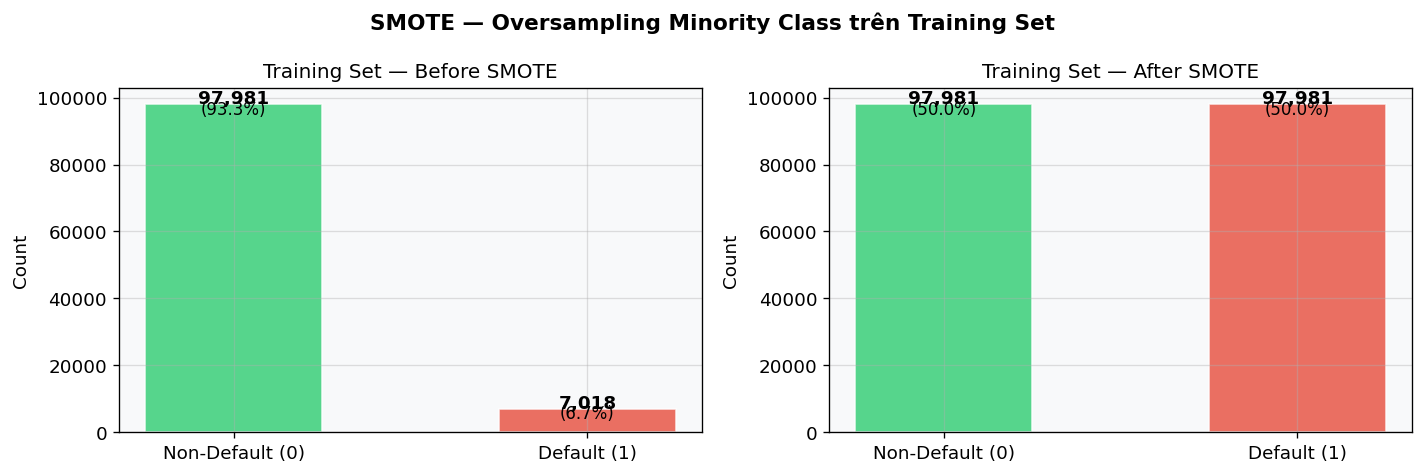

In [13]:
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("=== SMOTE Report ===")
print(f"Before SMOTE: {y_train.sum():,} positive, {len(y_train)-y_train.sum():,} negative")
print(f"After  SMOTE: {y_train_smote.sum():,} positive, "
      f"{len(y_train_smote)-y_train_smote.sum():,} negative")
print(f"New training size: {len(X_train_smote):,} rows (+{len(X_train_smote)-len(X_train):,} synthetic)")
print(f"\nVal/Test sets: KHÔNG thay đổi (giữ real distribution)")
print(f"  Val:  {y_val.sum():,} positive, positive rate = {y_val.mean()*100:.2f}%")
print(f"  Test: {y_test.sum():,} positive, positive rate = {y_test.mean()*100:.2f}%")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (X_s, y_s, title) in zip(axes, [
    (X_train, y_train, 'Training Set — Before SMOTE'),
    (X_train_smote, pd.Series(y_train_smote), 'Training Set — After SMOTE'),
]):
    counts = y_s.value_counts()
    ax.bar(['Non-Default (0)', 'Default (1)'], counts.values,
           color=[PALETTE['non_default'], PALETTE['default']],
           alpha=0.8, edgecolor='white', width=0.5)
    ax.set_title(title)
    ax.set_ylabel('Count')
    for i, (label, count) in enumerate(counts.items()):
        pct = count / len(y_s) * 100
        ax.text(i, count + 200, f'{count:,}', ha='center', fontweight='bold')
        ax.text(i, count - 3000, f'({pct:.1f}%)', ha='center', fontsize=10)

plt.suptitle('SMOTE — Oversampling Minority Class trên Training Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_15_smote.png', bbox_inches='tight', dpi=150)
plt.show()


## 10. sklearn Pipeline — Export cho Production

**Pipeline** đóng gói toàn bộ preprocessing vào một object duy nhất:

```python
Pipeline([
    ('imputer', KNNImputer(k=5)),    # Missing value imputation
    ('scaler', RobustScaler()),       # Feature scaling (Logistic Regression)
])
```

**Lý do dùng Pipeline thay vì manual steps:**
1. **No leakage**: fit_transform trên train → transform only trên val/test (đảm bảo imputer statistics từ train không leak vào test)
2. **Reproducibility**: một object duy nhất → easy to serialize và load
3. **Cross-validation safety**: Pipeline tích hợp với sklearn CV, fit preprocessing trên mỗi fold riêng

**Hai pipelines riêng biệt:**
- `preprocessing_pipeline`: imputation + scaling → dùng cho Logistic Regression
- `preprocessing_pipeline_tree`: chỉ imputation → dùng cho RF/XGBoost (không cần scaling)


In [14]:
# ─── Pipeline cho Logistic Regression (cần scaling) ─────────────────────
preprocessing_lr = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5, metric='nan_euclidean')),
    ('scaler', RobustScaler()),
])

# ─── Pipeline cho Tree-based models (không cần scaling) ──────────────────
preprocessing_tree = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5, metric='nan_euclidean')),
])

# Fit trên training set (không có SMOTE — fit preprocessing trước)
X_train_lr  = preprocessing_lr.fit_transform(X_train)
X_val_lr    = preprocessing_lr.transform(X_val)
X_test_lr   = preprocessing_lr.transform(X_test)

X_train_tree = preprocessing_tree.fit_transform(X_train)
X_val_tree   = preprocessing_tree.transform(X_val)
X_test_tree  = preprocessing_tree.transform(X_test)

print("Pipelines fitted on training set.")
print(f"X_train_lr shape:   {X_train_lr.shape}  (imputed + scaled)")
print(f"X_train_tree shape: {X_train_tree.shape} (imputed only)")

# Save pipelines
joblib.dump(preprocessing_lr, '../models/pipeline_lr.pkl')
joblib.dump(preprocessing_tree, '../models/pipeline_tree.pkl')
joblib.dump(preprocessing_lr, '../models/pipeline.pkl')  # main pipeline
print("\nSaved: models/pipeline_lr.pkl, models/pipeline_tree.pkl, models/pipeline.pkl")

# Save feature metadata
feature_meta = {
    'feature_cols': FINAL_FEATURES,
    'target_col': TARGET_COL,
    'n_original': 10,
    'n_engineered': 4,
    'engineered_names': new_features,
}
import json
with open('../models/feature_metadata.json', 'w') as f:
    json.dump(feature_meta, f, indent=2)
print("Saved: models/feature_metadata.json")


Pipelines fitted on training set.
X_train_lr shape:   (104999, 14)  (imputed + scaled)
X_train_tree shape: (104999, 14) (imputed only)

Saved: models/pipeline_lr.pkl, models/pipeline_tree.pkl, models/pipeline.pkl
Saved: models/feature_metadata.json


## 11. Preprocessing Summary

In [15]:
print("=" * 65)
print("PREPROCESSING SUMMARY")
print("=" * 65)
print(f"Input:  {ORIGINAL_SHAPE[0]:,} rows × {ORIGINAL_SHAPE[1]} columns (raw)")
print(f"Output: {len(df_feat):,} rows × {len(FINAL_FEATURES)} features + 1 target")
print()
print("Cleaning:")
print(f"  Removed age==0:      {ORIGINAL_SHAPE[0] - len(df_feat) - df['MonthlyIncome'].isnull().sum() + df_feat['MonthlyIncome'].isnull().sum():.0f} rows")
print(f"  Capped 8 features at p99")
print()
print("Imputation:")
print(f"  MonthlyIncome  ({df_raw['MonthlyIncome'].isnull().mean()*100:.1f}% missing): KNN(k=5)")
print(f"  Dependents     ({df_raw['NumberOfDependents'].isnull().mean()*100:.1f}% missing): Median")
print()
print("Feature Engineering (4 new):")
for feat in new_features:
    corr = abs(df_feat[feat].corr(df_feat[TARGET_COL], method='spearman'))
    print(f"  {feat}: ρ={corr:.3f}")
print()
print("Splits (stratified, random_state=42):")
for name, y_s in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f"  {name:5s}: {len(y_s):,} rows | {y_s.mean()*100:.2f}% positive")
print()
print("Pipelines saved:")
print("  models/pipeline_lr.pkl   (KNNImputer + RobustScaler)")
print("  models/pipeline_tree.pkl (KNNImputer only)")
print("  models/pipeline.pkl      (main pipeline = lr version)")
print("  models/feature_metadata.json")
print()
print("Splits saved:")
print("  data/splits/train.csv, val.csv, test.csv")
print()
print("Figures: reports/fig_11 to fig_15")


PREPROCESSING SUMMARY
Input:  150,000 rows × 11 columns (raw)
Output: 149,999 rows × 14 features + 1 target

Cleaning:
  Removed age==0:      -29730 rows
  Capped 8 features at p99

Imputation:
  MonthlyIncome  (19.8% missing): KNN(k=5)
  Dependents     (2.6% missing): Median

Feature Engineering (4 new):
  TotalDelinquencyScore: ρ=0.345
  FinancialStressIndex: ρ=0.346
  AbsoluteMonthlyDebt: ρ=0.016
  DelinquencyTrend: ρ=0.070

Splits (stratified, random_state=42):
  Train: 104,999 rows | 6.68% positive
  Val  : 22,500 rows | 6.68% positive
  Test : 22,500 rows | 6.68% positive

Pipelines saved:
  models/pipeline_lr.pkl   (KNNImputer + RobustScaler)
  models/pipeline_tree.pkl (KNNImputer only)
  models/pipeline.pkl      (main pipeline = lr version)
  models/feature_metadata.json

Splits saved:
  data/splits/train.csv, val.csv, test.csv

Figures: reports/fig_11 to fig_15
